<div style = "color:blue; font-size:25px">The goal of this project is to analyze factors affecting student's academic performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas import Series, DataFrame


<div style = "color:blue; font-size:25px">1. Loading Dataset

In [11]:
data = pd.read_csv('/home/kartika/Datasets/student_data.csv')
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15


<div style = "color:blue; font-size:25px">2. Basic Info about Dataset


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
data.duplicated().sum()

np.int64(0)

<div style = "color:blue; font-size:20px">No missing values and duplicate values.

<div>

<div>

<div style = "color:blue; font-size:25px">3. Filtering necessary columns

In [5]:
data.columns.unique()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

<div style = "color:blue; font-size:20px">Out of 33 columns,(school, sex, age, address, famsize, Parent Status, Medu, Fedu, Mjob, Fjob, traveltime, studytime
, failures, internet, freetime, goout, health, absences, G3) will be focused columns for this analysis.

In [16]:
data = data[['school','sex','age','address','famsize','Pstatus','Medu','Fedu','Mjob','Fjob','traveltime','studytime','failures','internet',
'freetime','absences','G3']]
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,internet,freetime,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,2,2,0,no,3,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,1,2,0,yes,3,4,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,1,2,3,yes,3,10,10
3,GP,F,15,U,GT3,T,4,2,health,services,1,3,0,yes,2,2,15
4,GP,F,16,U,GT3,T,3,3,other,other,1,2,0,no,3,4,10
5,GP,M,16,U,LE3,T,4,3,services,other,1,2,0,yes,4,10,15
6,GP,M,16,U,LE3,T,2,2,other,other,1,2,0,yes,4,0,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,2,2,0,no,1,6,6
8,GP,M,15,U,LE3,A,3,2,services,other,1,2,0,yes,2,0,19
9,GP,M,15,U,GT3,T,3,4,other,other,1,2,0,yes,5,0,15


<div>

<div>

<div style = "color:blue; font-size:25px">4.1 Number of males and females

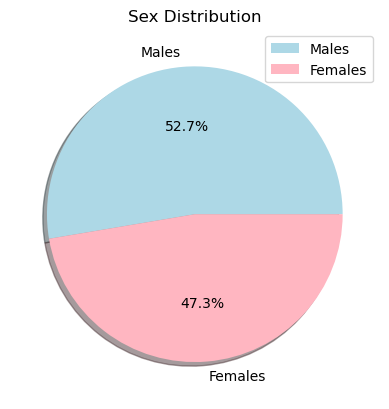

In [26]:
plt.pie(data['sex'].value_counts(), labels=['Males','Females'], colors = ['lightblue','lightpink'], autopct = "%1.1f%%", shadow = True)
plt.title("Sex Distribution")

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The distribution is almost balanced, but males are slightly more represented.

<div style = "color:blue; font-size:25px">4.2 Age Distribution

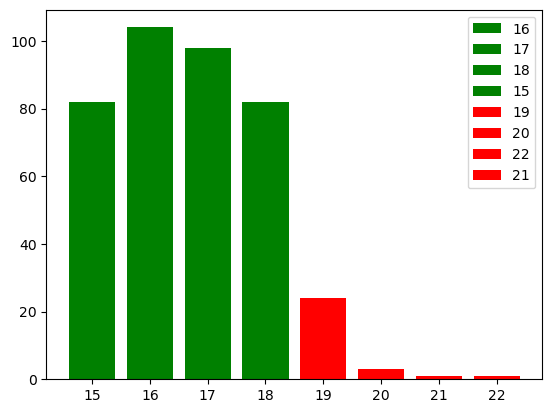

In [40]:
plt.bar(data['age'].value_counts().index, data['age'].value_counts().values,
 color = ['green','green','green','green','red','red','red','red'], label = data['age'].value_counts().index)

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px"> The dataset is dominated by teenagers (15-18), with highest reprsentation, while individuals above 19 years
constitue the smallest proportion.

<div style = "color:blue; font-size:25px">4.3 Urban vs Rural

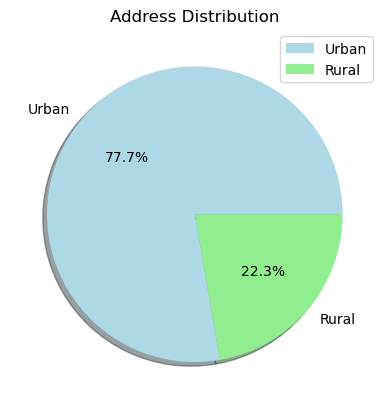

In [44]:
plt.pie(data.address.value_counts(), labels =['Urban','Rural'], colors = ['lightblue','lightgreen'], autopct = "%1.1f%%", shadow = True)

plt.title("Address Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The dataset is heavily dominated by urban students, while rural students account for much smaller proportion.